# Stock Price Dataset Analysis
EE 559 - Machine Learning I

Name: Sungje Park


In [104]:
import pandas as pd
import jax
import jax.numpy as jnp
import optax
import numpy as np
from tqdm import tqdm
from functools import partial
import matplotlib.pyplot as plt

## Data Loading

In [105]:
symbols = pd.read_csv('archive/symbols_valid_meta.csv')
stocks = symbols[symbols['ETF'] == 'N']
print(f"Number of stocks: {len(stocks)}")
stocks.head()

Number of stocks: 5884


,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
5,Y,AAL,"American Airlines Group, Inc. - Common Stock",Q,Q,N,100.0,N,N,NaN,AAL,N
6,Y,AAMC,Altisource Asset Management Corp Com,A,,N,100.0,N,NaN,AAMC,AAMC,N


In [106]:
def clean_symbol(symbol):
    return symbol

def load_stock_data(symbols):
    data = {}
    for symbol in symbols:
        symbol = clean_symbol(symbol)
        df = pd.read_csv(f'archive/stocks/{symbol}.csv', parse_dates=['Date'])
        df.set_index('Date', inplace=True)
        data[symbol] = df
    return data
stock_data = load_stock_data(stocks['NASDAQ Symbol'][:100])
print(stock_data.keys())
stock_data['A'].head()

dict_keys(['A', 'AA', 'AACG', 'AAL', 'AAMC', 'AAME', 'AAN', 'AAOI', 'AAON', 'AAP', 'AAPL', 'AAT', 'AAU', 'AAWW', 'AAXN', 'AB', 'ABB', 'ABBV', 'ABC', 'ABCB', 'ABEO', 'ABEV', 'ABG', 'ABIO', 'ABM', 'ABMD', 'ABR', 'ABT', 'ABTX', 'ABUS', 'AC', 'ACA', 'ACAD', 'ACAM', 'ACAMU', 'ACB', 'ACBI', 'ACC', 'ACCO', 'ACEL', 'ACER', 'ACGL', 'ACGLO', 'ACGLP', 'ACH', 'ACHC', 'ACHV', 'ACIA', 'ACIU', 'ACIW', 'ACLS', 'ACM', 'ACMR', 'ACN', 'ACNB', 'ACOR', 'ACP', 'ACRE', 'ACRS', 'ACRX', 'ACST', 'ACTG', 'ACTT', 'ACTTU', 'ACU', 'ACV', 'ACY', 'ADAP', 'ADBE', 'ADC', 'ADES', 'ADI', 'ADIL', 'ADM', 'ADMA', 'ADMP', 'ADMS', 'ADNT', 'ADP', 'ADPT', 'ADRO', 'ADS', 'ADSK', 'ADSW', 'ADT', 'ADTN', 'ADUS', 'ADVM', 'ADX', 'ADXN', 'ADXS', 'AE', 'AEB', 'AEE', 'AEF', 'AEFC', 'AEG', 'AEGN', 'AEHR', 'AEIS'])


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1999-11-18,32.546494,35.765381,28.612303,31.473534,27.068665,62546300
1999-11-19,30.713520,30.758226,28.478184,28.880543,24.838577,15234100
1999-11-22,29.551144,31.473534,28.657009,31.473534,27.068665,6577800
1999-11-23,30.400572,31.205294,28.612303,28.612303,24.607880,5975600
1999-11-24,28.701717,29.998211,28.612303,29.372318,25.261524,4843200


In [107]:
stock_data_combined = pd.concat(stock_data, axis=1, keys=stock_data.keys())
stock_data_combined.head()

/var/folders/2n/7nnz5dsd7j51q45dv749mhth0000gn/T/ipykernel_10099/406465815.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  stock_data_combined = pd.concat(stock_data, axis=1, keys=stock_data.keys())


A                                        AA                      \
           Open High Low Close Adj Close Volume      Open      High       Low   
Date                                                                            
1962-01-02  NaN  NaN NaN   NaN       NaN    NaN  6.532155  6.556185  6.532155   
1962-01-03  NaN  NaN NaN   NaN       NaN    NaN  6.532155  6.632280  6.524145   
1962-01-04  NaN  NaN NaN   NaN       NaN    NaN  6.632280  6.664320  6.632280   
1962-01-05  NaN  NaN NaN   NaN       NaN    NaN  6.632280  6.656310  6.616260   
1962-01-08  NaN  NaN NaN   NaN       NaN    NaN  6.608250  6.608250  6.339915   

                      ... AEHR                        AEIS                 \
               Close  ...  Low Close Adj Close Volume Open High Low Close   
Date                  ...                                                   
1962-01-02  6.532155  ...  NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN   
1962-01-03  6.632280  ...  NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN   
1962-01-04  6.632280  ...  NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN   
1962-01-05  6.624270  ...  NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN   
1962-01-08  6.408000  ...  NaN   NaN       NaN    NaN  NaN  NaN NaN   NaN   

                             
           Adj Close Volume  
Date                         
1962-01-02       NaN    NaN  
1962-01-03       NaN    NaN  
1962-01-04       NaN    NaN  
1962-01-05       NaN    NaN  
1962-01-08       NaN    NaN  

[5 rows x 600 columns]

## Pre-Processing

Check NA

In [108]:
# Detect any stocks with NA values
for stock, df in stock_data.items():
    if df.isna().sum().sum() > 0:
        print(f"{stock} has NA values.")
        print(f"Number of NA values in {stock}: {df.isna().sum().sum()}")
        df.dropna(inplace=True)  # Drop rows with NA values

ADP has NA values.
Number of NA values in ADP: 6


### Data Normalization & Feature Engineering

Report % change wrt. prev. day close & report relative volume

Also removes NA

In [109]:
price_cols = ['Open', 'High', 'Low', 'Close']
price_epsilon = 1e-8
vol_epsilon = 1

for stock, df in stock_data.items():
    # Calculate returns relative to previous close price
    prev_close = df['Close'].shift(1)
    for col in price_cols:
        df[f'{col}_ret_prev_close'] = df[col] / prev_close - 1

    df['rel_volume_yday'] = np.arcsinh(df['Volume'] / (df['Volume'].shift(1) + vol_epsilon) - 1) # Relative change in volume compared to previous day
    df['rel_adj_close'] = df['Adj Close'] / (df['Adj Close'].shift(1) + price_epsilon) - 1 # Relative change in adjusted close price compared to previous day
    # Include target variables for next day prediction
    df['target_rel_adj_close'] = df['rel_adj_close'].shift(-1)
    df['target_close'] = df['Close_ret_prev_close'].shift(-1)
    df.dropna(inplace=True)

stock_data['A'].head()

,Open,High,Low,Close,Adj Close,Volume,Open_ret_prev_close,High_ret_prev_close,Low_ret_prev_close,Close_ret_prev_close,rel_volume_yday,rel_adj_close,target_rel_adj_close,target_close
Date,,,,,,,,,,,,,,
1999-11-19,30.713520,30.758226,28.478184,28.880543,24.838577,15234100,-0.024148,-0.022727,-0.095170,-0.082386,-0.698287,-0.082386,0.089783,0.089783
1999-11-22,29.551144,31.473534,28.657009,31.473534,27.068665,6577800,0.023220,0.089783,-0.007740,0.089783,-0.541382,0.089783,-0.090909,-0.090909
1999-11-23,30.400572,31.205294,28.612303,28.612303,24.607880,5975600,-0.034091,-0.008523,-0.090909,-0.090909,-0.091423,-0.090909,0.026562,0.026563
1999-11-24,28.701717,29.998211,28.612303,29.372318,25.261524,4843200,0.003125,0.048437,0.000000,0.026563,-0.188388,0.026562,0.003044,0.003044
1999-11-26,29.238197,29.685265,29.148785,29.461731,25.338428,1729400,-0.004566,0.010654,-0.007610,0.003044,-0.605280,0.003044,0.022761,0.022762


In [110]:
price_cols = ["Open", "High", "Low", "Close", "Adj Close"]
return_cols = [
    "Open_ret_prev_close",
    "High_ret_prev_close",
    "Low_ret_prev_close",
    "Close_ret_prev_close",
    "rel_adj_close",
    "target_close",
    "target_rel_adj_close",
]

return_threshold = 10.0  # keep this for huge positive moves

cleaned_stock_data = {}
dropped_total = 0

for stock, df in stock_data.items():
    bad_mask = pd.Series(False, index=df.index)

    for col in price_cols:
        if col in df.columns:
            bad_mask |= df[col] <= 0

    for col in return_cols:
        if col in df.columns:
            bad_mask |= (~np.isfinite(df[col]))
            bad_mask |= (df[col] < -1)          # impossible for a return
            bad_mask |= (df[col] > return_threshold)

    dropped_total += int(bad_mask.sum())
    cleaned_stock_data[stock] = df.loc[~bad_mask].copy()

stock_data = cleaned_stock_data
print(f"Dropped rows: {dropped_total}")

Dropped rows: 15206


In [111]:
drop_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
final_data = {stock: df.drop(columns=drop_cols) for stock, df in stock_data.items()}
final_data_wide = pd.concat(final_data.values(), axis=1, keys=final_data.keys())
final_data_wide.head()

/var/folders/2n/7nnz5dsd7j51q45dv749mhth0000gn/T/ipykernel_10099/106948096.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  final_data_wide = pd.concat(final_data.values(), axis=1, keys=final_data.keys())


A                                         \
           Open_ret_prev_close High_ret_prev_close Low_ret_prev_close   
Date                                                                    
1962-01-03                 NaN                 NaN                NaN   
1962-01-04                 NaN                 NaN                NaN   
1962-01-05                 NaN                 NaN                NaN   
1962-01-08                 NaN                 NaN                NaN   
1962-01-09                 NaN                 NaN                NaN   

                                                               \
           Close_ret_prev_close rel_volume_yday rel_adj_close   
Date                                                            
1962-01-03                  NaN             NaN           NaN   
1962-01-04                  NaN             NaN           NaN   
1962-01-05                  NaN             NaN           NaN   
1962-01-08                  NaN             NaN           NaN   
1962-01-09                  NaN             NaN           NaN   

                                                              AA  \
           target_rel_adj_close target_close Open_ret_prev_close   
Date                                                               
1962-01-03                  NaN          NaN            0.000000   
1962-01-04                  NaN          NaN            0.000000   
1962-01-05                  NaN          NaN            0.000000   
1962-01-08                  NaN          NaN           -0.002418   
1962-01-09                  NaN          NaN            0.000000   

                                ...                 AEHR               \
           High_ret_prev_close  ... target_rel_adj_close target_close   
Date                            ...                                     
1962-01-03            0.015328  ...                  NaN          NaN   
1962-01-04            0.004831  ...                  NaN          NaN   
1962-01-05            0.003623  ...                  NaN          NaN   
1962-01-08           -0.002418  ...                  NaN          NaN   
1962-01-09            0.015625  ...                  NaN          NaN   

                          AEIS                                         \
           Open_ret_prev_close High_ret_prev_close Low_ret_prev_close   
Date                                                                    
1962-01-03                 NaN                 NaN                NaN   
1962-01-04                 NaN                 NaN                NaN   
1962-01-05                 NaN                 NaN                NaN   
1962-01-08                 NaN                 NaN                NaN   
1962-01-09                 NaN                 NaN                NaN   

                                                               \
           Close_ret_prev_close rel_volume_yday rel_adj_close   
Date                                                            
1962-01-03                  NaN             NaN           NaN   
1962-01-04                  NaN             NaN           NaN   
1962-01-05                  NaN             NaN           NaN   
1962-01-08                  NaN             NaN           NaN   
1962-01-09                  NaN             NaN           NaN   

                                              
           target_rel_adj_close target_close  
Date                                          
1962-01-03                  NaN          NaN  
1962-01-04                  NaN          NaN  
1962-01-05                  NaN          NaN  
1962-01-08                  NaN          NaN  
1962-01-09                  NaN          NaN  

[5 rows x 800 columns]

In [112]:
final_data_tall = pd.concat([df.assign(stock=stock).reset_index() for stock, df in final_data.items()],axis=0,ignore_index=True)
final_data_tall.sort_values(['Date'], inplace=True)
final_data_tall.reset_index(drop=True, inplace=True)
final_data_tall.head()

,Date,Open_ret_prev_close,High_ret_prev_close,Low_ret_prev_close,Close_ret_prev_close,rel_volume_yday,rel_adj_close,target_rel_adj_close,target_close,stock
0,1962-01-03,0.000000,0.015328,-0.001226,0.015328,0.326862,1.532820e-02,-6.409386e-09,0.000000,AA
1,1962-01-04,0.000000,0.004831,0.000000,0.000000,0.080436,-6.409386e-09,-1.208365e-03,-0.001208,AA
2,1962-01-05,0.000000,0.003623,-0.002415,-0.001208,-0.123917,-1.208365e-03,-3.264794e-02,-0.032648,AA
3,1962-01-08,-0.002418,-0.002418,-0.042926,-0.032648,0.324740,-3.264794e-02,-8.124931e-03,-0.008125,AA
4,1962-01-09,0.000000,0.015625,-0.008125,-0.008125,-0.307505,-8.124931e-03,1.260491e-03,0.001260,AA


Seperate training, validation, and test datasets

In [113]:
drop_cols = ['stock','target_close','Date']

final_data_tall = final_data_tall.drop(columns=drop_cols)

data_size = len(final_data_tall)
print(f"Total data points: {data_size}")
train_data_ind = int(data_size * 0.7)
valid_data_ind = int(data_size * 0.85)
test_data_ind = int(data_size)

print(f"Train data points: {train_data_ind}, Validation data points: {valid_data_ind - train_data_ind}, Test data points: {test_data_ind - valid_data_ind}")

train_data = final_data_tall.iloc[:train_data_ind]
valid_data = final_data_tall.iloc[train_data_ind:valid_data_ind]
test_data = final_data_tall.iloc[valid_data_ind:]

print(f"Train data shape: {train_data.shape}, Validation data shape: {valid_data.shape}, Test data shape: {test_data.shape}")

Total data points: 432227
Train data points: 302558, Validation data points: 64834, Test data points: 64835
Train data shape: (302558, 7), Validation data shape: (64834, 7), Test data shape: (64835, 7)


In [114]:
def seperate_x_y(df):
    x = jnp.asarray(df.drop(columns=['target_rel_adj_close']))
    y = jnp.asarray(df['target_rel_adj_close'])[...,jnp.newaxis]
    return x, y

train_data_x,train_data_y = seperate_x_y(train_data)
valid_data_x,valid_data_y = seperate_x_y(valid_data)
test_data_x,test_data_y = seperate_x_y(test_data)
print(f"Train data X shape: {train_data_x.shape}, Train data Y shape: {train_data_y.shape}")

Train data X shape: (302558, 6), Train data Y shape: (302558, 1)


In [115]:
print(jnp.max(train_data_y), jnp.min(train_data_y))

9.931351 -0.9853556


In [116]:
train_data.isna().sum()

Open_ret_prev_close     0
High_ret_prev_close     0
Low_ret_prev_close      0
Close_ret_prev_close    0
rel_volume_yday         0
rel_adj_close           0
target_rel_adj_close    0
dtype: int64

## Basic NN Training

In [117]:
from models import BasicNetwork

num_layers = 5
d_hidden = 256
seed = 1234
lr = 1e-4
batch_size = 2056

nn = BasicNetwork(num_layers=num_layers,d_hidden=d_hidden)
params = nn.init(jax.random.PRNGKey(seed),train_data_x[:10])
num_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters in the model: {num_params}")

Number of parameters in the model: 265217


### Loss Def

In [118]:
def mse_loss(params,model,x,y):
    preds = model.apply(params,x)
    return jnp.mean((preds - y)**2)
# print(mse_loss(params,nn,train_data_x,train_data_y))

In [119]:
def subsample_data(key,x,y,batch_size):
    ind = jax.random.randint(key,shape=(batch_size,),minval=0,maxval=x.shape[0])
    return x[ind], y[ind]

In [120]:
optimizer = optax.adam(learning_rate=lr)
opt_state = optimizer.init(params)

In [121]:
@partial(jax.jit, static_argnums=0)
def step(model,params,opt_state,x,y,rng_key):
    rng_key, subkey = jax.random.split(rng_key)
    x,y = subsample_data(subkey,x,y,batch_size)
    loss, grads = jax.value_and_grad(mse_loss,argnums=0)(params,model,x,y)
    updates, opt_state = optimizer.update(grads,opt_state)
    params = optax.apply_updates(params,updates)
    return params,opt_state,loss,rng_key

@partial(jax.jit, static_argnums=0)
def evaluate(model,params,key,x,y):
    x,y = subsample_data(key,x,y,batch_size)
    return mse_loss(params,model,x,y)

### Training

In [122]:
rng_key = jax.random.PRNGKey(seed)
loss_track = []
v_loss_track = []
for _ in tqdm(range(10000)):
    params,opt_state,loss,rng_key = step(nn,params,opt_state,train_data_x,train_data_y,rng_key)
    v_loss = evaluate(nn,params,rng_key,valid_data_x,valid_data_y)
    loss_track.append(loss)
    v_loss_track.append(v_loss)

100%|██████████| 10000/10000 [03:32<00:00, 47.05it/s]


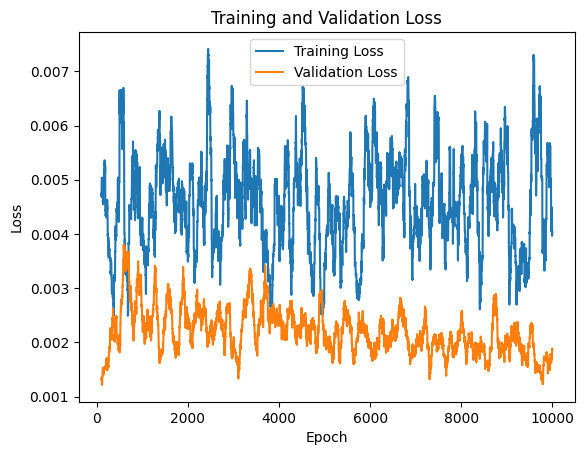

In [123]:
rolling_loss = pd.Series(loss_track).rolling(window=100).mean()
rolling_v_loss = pd.Series(v_loss_track).rolling(window=100).mean()

plt.plot(rolling_loss)
plt.plot(rolling_v_loss)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

In [124]:
def evaluate(x,y):
    pred = nn.apply(params,x)

    mse = jnp.mean((pred - y)**2)
    corr = jnp.corrcoef(pred.flatten(), y.flatten())[0,1]
    sign_pred = jnp.sign(pred.flatten())
    sign_true = jnp.sign(y.flatten())
    accuracy = jnp.mean(sign_pred == sign_true)
    return mse, corr, accuracy
def print_eval_metrics(mse, corr, acc, dataset_name):
    print(f"{dataset_name} MSE: {mse:.6f}, Correlation: {corr:.4f}, Sign Accuracy: {acc:.4f}")

In [125]:
eval_batch_size = 100000

eval_train_data_x, eval_train_data_y = subsample_data(rng_key,train_data_x,train_data_y,eval_batch_size)
eval_valid_data_x, eval_valid_data_y = subsample_data(rng_key,valid_data_x,valid_data_y,eval_batch_size)
eval_test_data_x, eval_test_data_y = subsample_data(rng_key,test_data_x,test_data_y,eval_batch_size)

train_mse, train_corr, train_acc = evaluate(eval_train_data_x, eval_train_data_y)
print_eval_metrics(train_mse, train_corr, train_acc, "Train")
valid_mse, valid_corr, valid_acc = evaluate(eval_valid_data_x, eval_valid_data_y)
print_eval_metrics(valid_mse, valid_corr, valid_acc, "Validation")
test_mse, test_corr, test_acc = evaluate(eval_test_data_x, eval_test_data_y)
print_eval_metrics(test_mse, test_corr, test_acc, "Test")

Train MSE: 0.004469, Correlation: 0.3301, Sign Accuracy: 0.5460
Validation MSE: 0.002515, Correlation: 0.0007, Sign Accuracy: 0.5106
Test MSE: 0.001505, Correlation: 0.0441, Sign Accuracy: 0.5077


Validation Eval


Train
TN=41375 FP=14325 FN=30990 TP=13310
Acc=0.5468  Prec=0.4816  Rec=0.3005  Spec=0.7428  F1=0.3701  BalAcc=0.5216


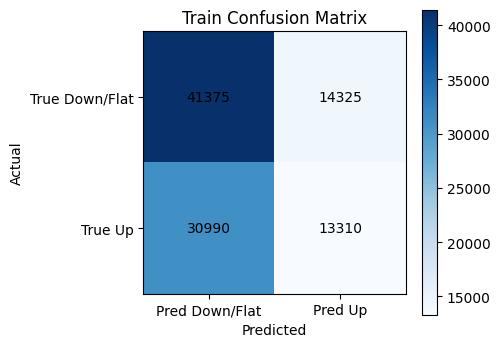


Validation
TN=38428 FP=12855 FN=36087 TP=12630
Acc=0.5106  Prec=0.4956  Rec=0.2593  Spec=0.7493  F1=0.3404  BalAcc=0.5043


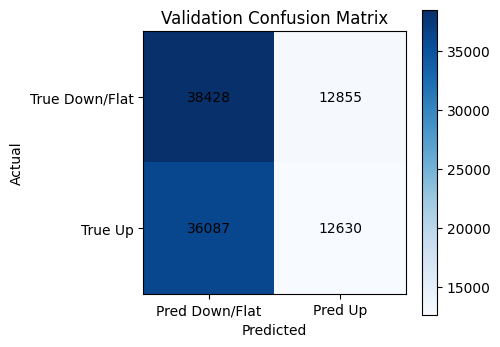


Test
TN=37183 FP=14190 FN=35040 TP=13587
Acc=0.5077  Prec=0.4891  Rec=0.2794  Spec=0.7238  F1=0.3557  BalAcc=0.5016


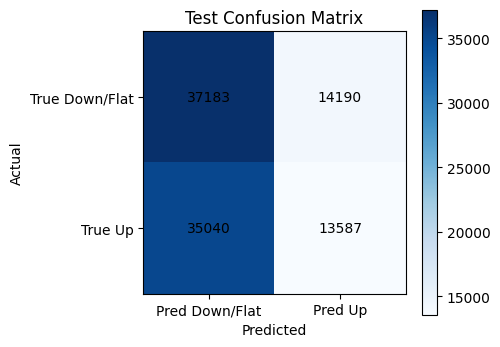

In [126]:
def confusion_and_metrics(x, y, threshold=0.0):
    # Predictions and labels
    pred = np.asarray(nn.apply(params, x)).reshape(-1)
    true = np.asarray(y).reshape(-1)

    y_pred = (pred > threshold).astype(int)
    y_true = (true > threshold).astype(int)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    eps = 1e-12
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)          # sensitivity / TPR
    specificity = tn / (tn + fp + eps)     # TNR
    f1 = 2 * precision * recall / (precision + recall + eps)
    balanced_acc = 0.5 * (recall + specificity)

    cm = np.array([[tn, fp],
                   [fn, tp]], dtype=int)

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "balanced_accuracy": balanced_acc
    }
    return cm, metrics

def plot_confusion(cm, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Down/Flat", "Pred Up"])
    ax.set_yticklabels(["True Down/Flat", "True Up"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

    # annotate cells
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

    plt.tight_layout()
    plt.show()

# Example usage on train/valid/test
for name, x, y in [
    ("Train", eval_train_data_x, eval_train_data_y),
    ("Validation", eval_valid_data_x, eval_valid_data_y),
    ("Test", eval_test_data_x, eval_test_data_y),
]:
    cm, m = confusion_and_metrics(x,y, threshold=0.0)
    print(f"\n{name}")
    print(f"TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")
    print(
        f"Acc={m['accuracy']:.4f}  Prec={m['precision']:.4f}  "
        f"Rec={m['recall']:.4f}  Spec={m['specificity']:.4f}  "
        f"F1={m['f1']:.4f}  BalAcc={m['balanced_accuracy']:.4f}"
    )
    plot_confusion(cm, title=f"{name} Confusion Matrix")